# Project Overview & Metadata Summary

Dataset Source: World Health Organization (WHO) Excess Mortality Dataset.   
Primary Objective: Analyze excess deaths associated with the COVID-19 pandemic across countries for the years 2020, 2021, and the cumulative period 2020–2021.   

Key Indicators:

excess.mean: Point estimate of excess deaths.   
excess.low: Lower bound of 95% confidence interval.   
excess.high: Upper bound of 95% confidence interval.

Exploratory Data Analysis (EDA) HighlightsData 

Structure Quick-CheckTotal 

Columns: 6 (Country, iso3, year, excess.mean, excess.low, excess.high).   
Missing Values: Run df.isnull().sum() to verify missing data in baseline estimates.
Uncertainty Margin: ci_range = df['excess.high'] - df['excess.low'] measures model variance per country.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/who.xlsx', sheet_name = 'Deaths by year', skiprows=7)

In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
df.head()

,Country,iso3,year,excess.mean*,excess.low*,excess.high*
0,Afghanistan,AFG,2020,26953.949030,4791.781402,51031.42258
1,Afghanistan,AFG,2021,38779.408960,15704.016300,62392.11979
2,Afghanistan,AFG,2020-2021,65733.358000,32745.836540,100857.97600
3,Angola,AGO,2020,553.169164,-16951.755910,17781.72667
4,Angola,AGO,2021,10442.445700,-7477.303324,30453.39688


In [5]:
df.tail()

,Country,iso3,year,excess.mean*,excess.low*,excess.high*
579,Zimbabwe,ZWE,2020,2160.553146,-7037.822287,11488.24492
580,Zimbabwe,ZWE,2021,14392.375170,4340.492488,24532.71691
581,Zimbabwe,ZWE,2020-2021,16552.928320,1835.390847,30982.19509
582,NaN,NaN,NaN,NaN,NaN,NaN
583,"* Deaths caused by other shocks, such as confl...",NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(584, 6)

In [7]:
df.columns

Index(['Country', 'iso3', 'year', 'excess.mean*', 'excess.low*',
       'excess.high*'],
      dtype='object')

In [8]:
df.dtypes

Country          object
iso3             object
year             object
excess.mean*    float64
excess.low*     float64
excess.high*    float64
dtype: object

In [9]:
# Clean column names (remove asterisks and trailing spaces)
df.columns = df.columns.str.replace('*', '', regex=False).str.strip()

# View the first few rows
print(df.head())

       Country iso3       year   excess.mean    excess.low   excess.high
0  Afghanistan  AFG       2020  26953.949030   4791.781402   51031.42258
1  Afghanistan  AFG       2021  38779.408960  15704.016300   62392.11979
2  Afghanistan  AFG  2020-2021  65733.358000  32745.836540  100857.97600
3       Angola  AGO       2020    553.169164 -16951.755910   17781.72667
4       Angola  AGO       2021  10442.445700  -7477.303324   30453.39688


In [10]:
type(df.columns)

pandas.core.indexes.base.Index

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      583 non-null    object 
 1   iso3         582 non-null    object 
 2   year         582 non-null    object 
 3   excess.mean  582 non-null    float64
 4   excess.low   582 non-null    float64
 5   excess.high  582 non-null    float64
dtypes: float64(3), object(3)
memory usage: 27.5+ KB


In [12]:
df.describe()

,excess.mean,excess.low,excess.high
count,5.820000e+02,5.820000e+02,5.820000e+02
mean,5.107521e+04,3.615381e+04,6.772568e+04
std,2.764130e+05,2.021353e+05,3.732753e+05
min,-7.547288e+04,-2.416335e+05,-6.609636e+04
25%,6.109889e+02,-3.653004e+02,1.584643e+03
50%,5.872359e+03,9.030796e+02,1.034253e+04
75%,2.106947e+04,1.260385e+04,3.490767e+04
max,4.734516e+06,3.315582e+06,6.479563e+06


In [13]:
# missing data

missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Country        1
iso3           2
year           2
excess.mean    2
excess.low     2
excess.high    2
dtype: int64


In [14]:
type(missing_data)

pandas.core.series.Series

In [15]:
type(df)

pandas.core.frame.DataFrame

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]

,Country,iso3,year,excess.mean,excess.low,excess.high


In [18]:
df["year"].unique()

array([2020, 2021, '2020-2021', nan], dtype=object)

In [19]:
# to stablished correlation between variable excess.low and excess.high

numeric_values = ["excess.low", "excess.high"]

correlation = df[numeric_values].corr()

print(correlation)

             excess.low  excess.high
excess.low     1.000000     0.963822
excess.high    0.963822     1.000000


In [20]:
missing_rows = df[df['excess.low'].isnull()]
print(missing_rows)

                                               Country iso3 year  excess.mean  \
582                                                NaN  NaN  NaN          NaN   
583  * Deaths caused by other shocks, such as confl...  NaN  NaN          NaN   

     excess.low  excess.high  
582         NaN          NaN  
583         NaN          NaN  


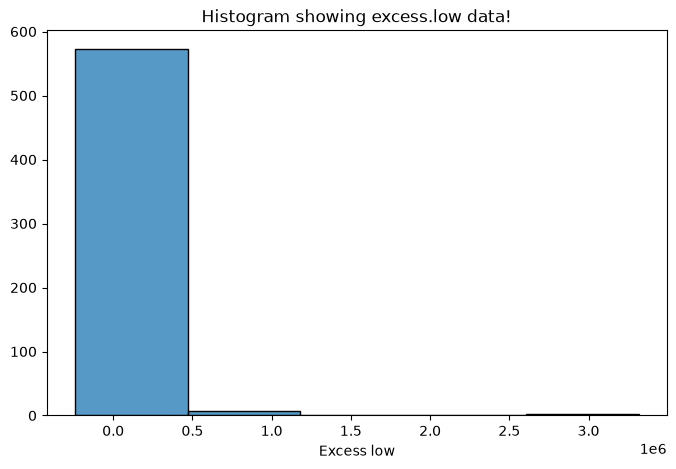

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["excess.low"], bins=5,
    edgecolor="black")
plt.title("Histogram showing excess.low data!")
plt.xlabel("Excess low")
plt.ylabel("")

plt.savefig("../images/histogram_showingExcess Low.png")
plt.show()

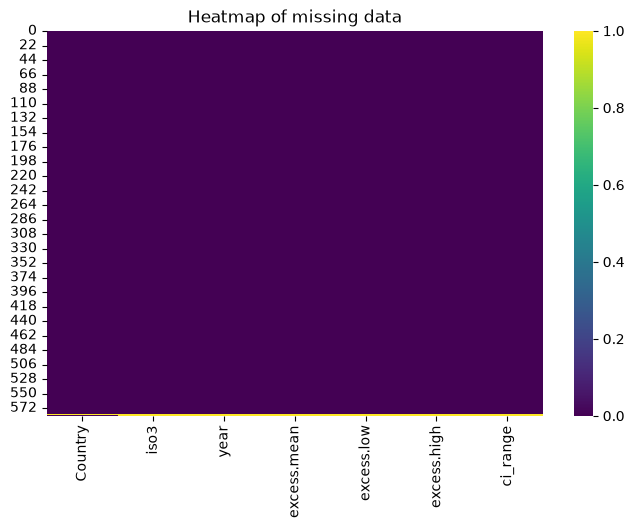

In [32]:
# visualizing missing data

plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cmap="viridis")

plt.title("Heatmap of missing data")
plt.savefig("../images/heatmap missingdat.png")
plt.show()

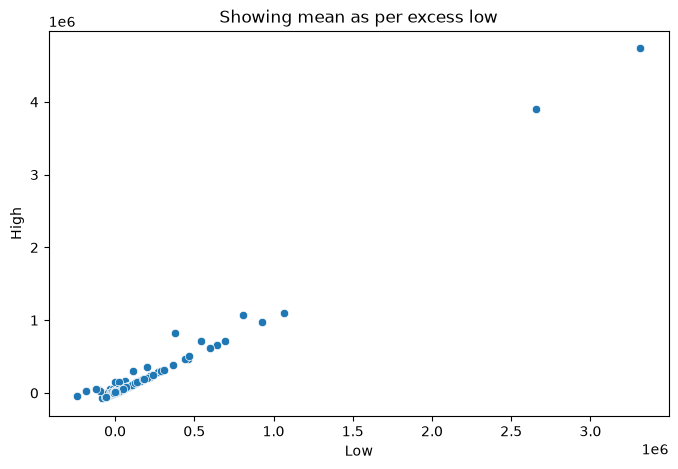

In [33]:
# visualizing missing data

plt.figure(figsize=(8,5))

sns.scatterplot(x=df["excess.low"], y=df["excess.mean"])

plt.title("Showing mean as per excess low")
plt.xlabel("Low")
plt.ylabel("High")
plt.savefig("../images/mean showing.png")
plt.show()

In [24]:
# Clean year values 

df_yearly = df[df['year']  != '2020-2021'].copy()
type(df_yearly)
df_yearly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 583
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      389 non-null    object 
 1   iso3         388 non-null    object 
 2   year         388 non-null    object 
 3   excess.mean  388 non-null    float64
 4   excess.low   388 non-null    float64
 5   excess.high  388 non-null    float64
dtypes: float64(3), object(3)
memory usage: 21.3+ KB


In [25]:
df_yearly['year'] = df_yearly['year'].astype('Int64')

In [26]:
df_yearly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 583
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      389 non-null    object 
 1   iso3         388 non-null    object 
 2   year         388 non-null    Int64  
 3   excess.mean  388 non-null    float64
 4   excess.low   388 non-null    float64
 5   excess.high  388 non-null    float64
dtypes: Int64(1), float64(3), object(2)
memory usage: 21.7+ KB


In [27]:
# Summary statistics for numeric columns
print(df_yearly[['excess.mean', 'excess.low', 'excess.high']].describe())

        excess.mean    excess.low   excess.high
count  3.880000e+02  3.880000e+02  3.880000e+02
mean   3.830641e+04  2.569156e+04  5.233960e+04
std    2.159291e+05  1.537251e+05  2.980448e+05
min   -7.547288e+04 -1.825078e+05 -6.609636e+04
25%    4.199334e+02 -5.384400e+02  1.209439e+03
50%    4.372153e+03  5.139250e+02  8.268432e+03
75%    1.655509e+04  9.675410e+03  2.860079e+04
max    3.905102e+06  2.657961e+06  5.481097e+06


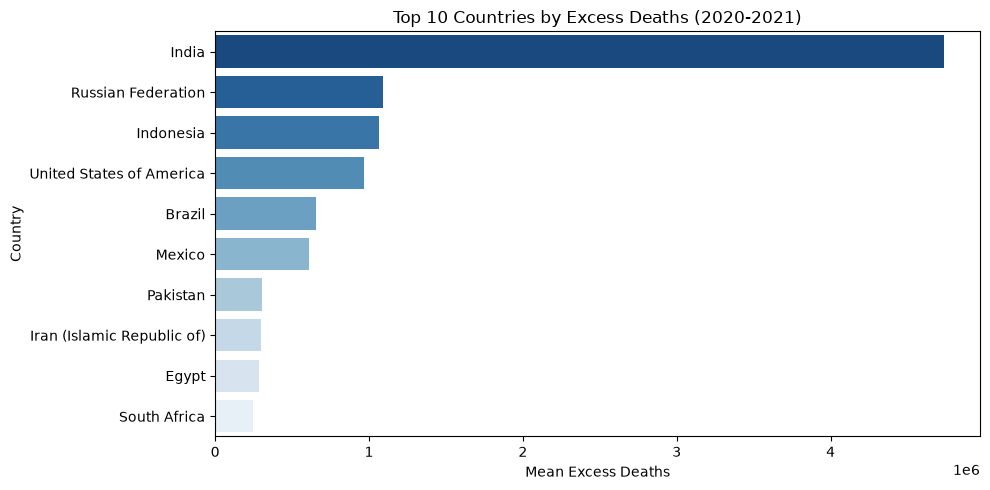

In [35]:
# Visualization & Key Insights
# Top 10 Countries by Total Mean Excess Deaths (2020–2021)

df_total = df[df['year'] == '2020-2021']
top_10 = df_total.sort_values(by='excess.mean', ascending= False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_10, 
    x='excess.mean', 
    y='Country', 
    hue='Country', 
    palette='Blues_r', 
    legend=False
)
plt.title('Top 10 Countries by Excess Deaths (2020-2021)')
plt.xlabel('Mean Excess Deaths')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig("../images/excessDeath.png")

plt.show()

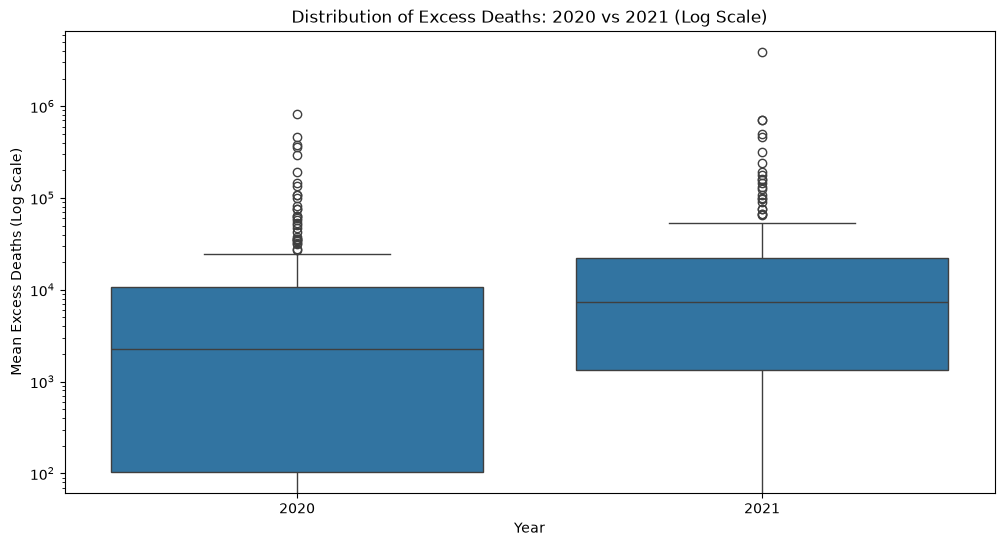

In [36]:
# Year-over-Year Comparison (2020 vs 2021)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_yearly, x='year', y='excess.mean')
plt.yscale('log')  # Log scale helps deal with skewed/large distributions
plt.title('Distribution of Excess Deaths: 2020 vs 2021 (Log Scale)')
plt.xlabel('Year')
plt.ylabel('Mean Excess Deaths (Log Scale)')
plt.savefig("../images/excessDeathbodplot.png")
plt.show()

In [30]:
# Confidence Interval Margin Analysis

df['ci_range'] = df['excess.high'] - df['excess.low'] 

print(df.sort_values(by='ci_range', ascending=False)[['Country', 'year', 'ci_range']].head())


       Country       year      ci_range
236      India  2020-2021  3.163981e+06
235      India       2021  2.823136e+06
234      India       2020  9.429301e+05
233  Indonesia  2020-2021  5.370347e+05
562   Viet Nam       2021  4.424390e+05
